# 🏃‍♂️ How Weather Impacts Marathon Performance

## Introduction

Marathon performance is influenced by a combination of physiological, environmental, and race-specific factors. Among these, weather conditions such as temperature, humidity, and wind may play a crucial role in determining race outcomes.

This project explores how environmental conditions impact marathon performance by combining global data from World Marathon Majors with a detailed runner-level analysis of the London Marathon.

The analysis aims to identify patterns in performance across different races and evaluate whether weather conditions have a measurable effect on finishing times.

## Data Overview

The analysis is based on two main datasets:

- **World Marathon Majors dataset**: aggregated race-level data across major marathons
- **London Marathon dataset**: runner-level data including elite and mass participants

Before starting the analysis, both datasets are inspected to understand their structure, variables, and data quality.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.max_columns", None)

In [2]:
df_london = pd.read_csv("../data/processed/final/london_marathon_final_dataset.csv")
df_majors = pd.read_csv("../data/processed/majors/majors_cleaned.csv")

In [135]:
print("Majors dataset shape:", df_majors.shape)

Majors dataset shape: (7, 29)


In [11]:
df_majors.head(7)

,Marathon,City,Country,Date,Year,Elite_time_winner_m,Elite_time_winner_m_seconds,Pace_elite_m,Elite_time_winner_f,Elite_time_winner_f_seconds,Pace_elite_f,Average_men_time,Average_men_time_seconds,Pace_avg_men,Average_women_time,Average_women_time_seconds,Pace_avg_women,Participants,Finishers,Completion_rate,Temperature_start_c,Humidity_pct,Wind_speed_kmh,Elevation_gain_m,Weather_notes,Course_type,Applications,Source,Notes
0,Berlin Marathon,Berlin,Germany,21-09-2025,2025,02:02:16,7336,2.90,02:21:08,8468,3.34,04:37:19,16639.0,6.57,NaN,NaN,NaN,55000,48020,87.3,19.0,68,14.4,25,Temperatura mas alta registrada,Flat urban course,170000,"BMW Berlin Marathon website, Findmymarathon we...",Numero aproximado de participantes (no oficial...
1,Boston Marathon,Boston,USA,21-04-2025,2025,02:04:45,7485,2.96,02:17:22,8242,3.26,03:33:31,12811.0,5.06,03:56:02,14162.0,5.59,28845,28409,98.5,9.0,35,8.0,248,Partially clouded,Point to Point road/pavement,36393,"Boston Athletic Association website, Findmymar...",Datos introducidos manualmente. Elevation gain...
2,Chicago Marathon,Chicago,USA,2025-10-12,2025,02:02:23,7343,2.90,02:14:57,8097,3.20,03:55:44,14144.0,5.59,04:32:48,16368.0,6.47,55000,54383,98.8,10.0,85,4.8,35,Partially cloudy,Flat and looped road course,160000,Bank of America Chicago Marathon official webs...,Numero aproximado de participantes (no oficial...
3,London Marathon,London,UK,27-04-2025,2025,02:02:27,7347,2.90,02:15:50,8150,3.22,04:23:00,15780.0,6.23,05:01:00,18060.0,7.13,64053,56640,88.4,12.0,76,3.2,127,Despejado y soleado,Flat urban course,840318,"TCS London Marathon website, Findmymarathon we...",Datos introducidos manualmente. Elevation gain...
4,New York Marathon,New York,USA,02-11-2025,2025,02:08:09,7689,3.04,02:19:51,8391,3.31,04:18:55,15535.0,6.14,04:48:11,17291.0,6.83,59662,59221,99.3,7.0,69,NaN,246,No habia viento este dia,Point to Point road racing course,200000,"TCS New York Marathon website, Findmymarathon ...",Datos introducidos manualmente. Elevation gain...
5,Sydney Marathon,Sydney,Australia,31-08-2025,2025,02:06:06,7566,2.99,02:18:22,8302,3.28,NaN,NaN,NaN,NaN,NaN,NaN,35000,32976,94.2,8.0,64,13.0,317,Clear,Point to Point road/pavement,79000,"TCS SYdney Marathon website, Findmymarathon we...",Datos introducidos manualmente. Elevation gain...
6,Tokyo Marathon,Tokyo,Japan,2025-03-02,2025,02:03:23,7403,2.92,02:16:31,8191,3.24,04:41:00,16860.0,6.66,05:04:00,18240.0,7.20,37791,36204,96.6,8.0,58,1.1,45,Cool and dry,Flat urban loop,300000,Official Tokyo Marathon website + official res...,Datos introducidos manualmente. Tiempos averag...


In [13]:
df_majors.info()

<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 29 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   Marathon                     7 non-null      str    
 1   City                         7 non-null      str    
 2   Country                      7 non-null      str    
 3   Date                         7 non-null      str    
 4   Year                         7 non-null      int64  
 5   Elite_time_winner_m          7 non-null      str    
 6   Elite_time_winner_m_seconds  7 non-null      int64  
 7   Pace_elite_m                 7 non-null      float64
 8   Elite_time_winner_f          7 non-null      str    
 9   Elite_time_winner_f_seconds  7 non-null      int64  
 10  Pace_elite_f                 7 non-null      float64
 11  Average_men_time             6 non-null      str    
 12  Average_men_time_seconds     6 non-null      float64
 13  Pace_avg_men                 6 non-

Both datasets were successfully loaded and contain the expected variables for performance and weather analysis.

The London dataset provides detailed runner-level data, while the majors dataset offers a broader, aggregated perspective across events. This combination enables both macro and micro-level analysis.

## Global EDA: World Marathon Majors

This section explores performance patterns across major marathons. The objective is to identify differences between races and examine whether weather conditions are associated with performance outcomes.

### Participation and Completion

We begin by comparing participation levels and completion rates across marathons to understand differences in race accessibility and difficulty.

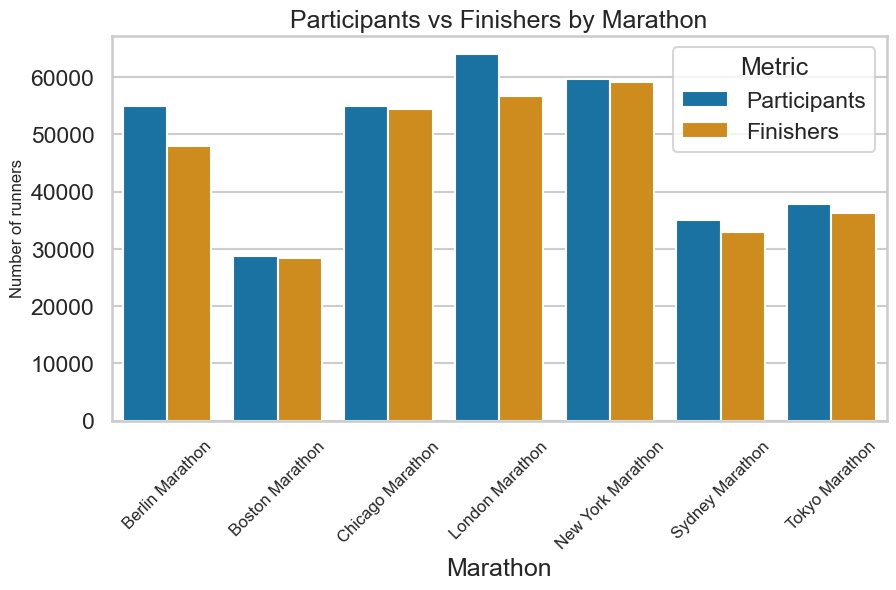

In [130]:
df_participants = (
    df_majors.groupby("Marathon", as_index=False)[
        ["Participants", "Finishers"]
    ]
    .mean()
)

df_melted = df_participants.melt(
    id_vars="Marathon",
    value_vars=["Participants", "Finishers"],
    var_name="Metric",
    value_name="Count"
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=df_melted,
    x="Marathon",
    y="Count",
    hue="Metric",
    palette={"Participants": "#0479B8", "Finishers": "#EA9400"}
)

plt.title("Participants vs Finishers by Marathon")
plt.xticks(rotation=45, fontsize=12)
plt.ylabel("Number of runners", fontsize=12)

plt.show()

Participation varies significantly across marathons, reflecting differences in scale and global popularity.

Completion rate provides a more meaningful metric of race difficulty, as it accounts for the proportion of runners who successfully finish the race.

### Completion Rate and Elevation

To further explore race difficulty, elevation gain is introduced alongside completion rate.

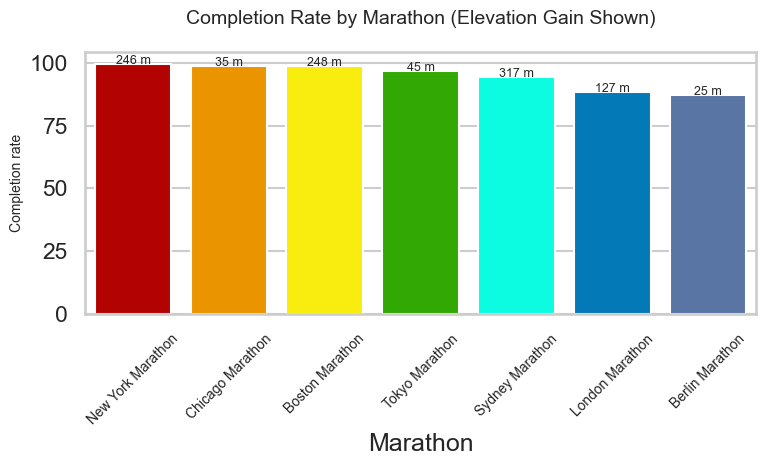

In [118]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=df_completion,
    x="Marathon",
    y="Completion_rate"
)

colors = ["#B20202", "#EA9400", "#F8ED0E", "#31A803", "#0BFCE0", "#0479B8"]
for bar, color in zip(ax.patches, colors):
    bar.set_facecolor(color)

for i, row in df_completion.iterrows():
    ax.text(
        i,
        row["Completion_rate"] + 0.002,
        f"{int(row['Elevation_gain_m'])} m",
        ha='center',
        fontsize=9
    )

plt.title("Completion Rate by Marathon (Elevation Gain Shown)", pad=20, fontsize=14)
plt.xticks(rotation=45, fontsize=10)
plt.ylabel("Completion rate", fontsize=10)

plt.tight_layout()
plt.show()

In [70]:
df_elevation = (
    df_majors.groupby("Marathon", as_index=False)["Elevation_gain_m"]
    .mean()
)

df_completion = df_completion.merge(df_elevation, on="Marathon")

Despite differences in elevation gain across marathons, completion rates remain consistently high, even for courses with higher elevation.

Notably, marathons such as New York and Boston, which have relatively high elevation gains, still exhibit strong completion rates.

This suggests that elevation alone may not be a decisive factor in determining race completion, and that other elements such as weather conditions or runner characteristics may play a more significant role.

### Temperature in Flat Marathons

To isolate the effect of weather, the analysis focuses on flat marathons (Berlin, Chicago, and Tokyo), where elevation is not a major factor.

In [50]:
df_long["avg_time_hours"] = df_long["average_time_seconds"] / 3600

In [58]:
flat_marathons = ["Berlin Marathon", "Chicago Marathon", "Tokyo Marathon"]

df_flat = df_majors[df_majors["Marathon"].isin(flat_marathons)].copy()

In [59]:
df_flat_grouped = (
    df_flat.groupby("Marathon", as_index=False)
    .agg({
        "Temperature_start_c": "mean",
        "Participants": "mean",
        "Finishers": "mean"
    })
)

In [60]:
df_flat_grouped["Completion_rate"] = (
    df_flat_grouped["Finishers"] / df_flat_grouped["Participants"]
)

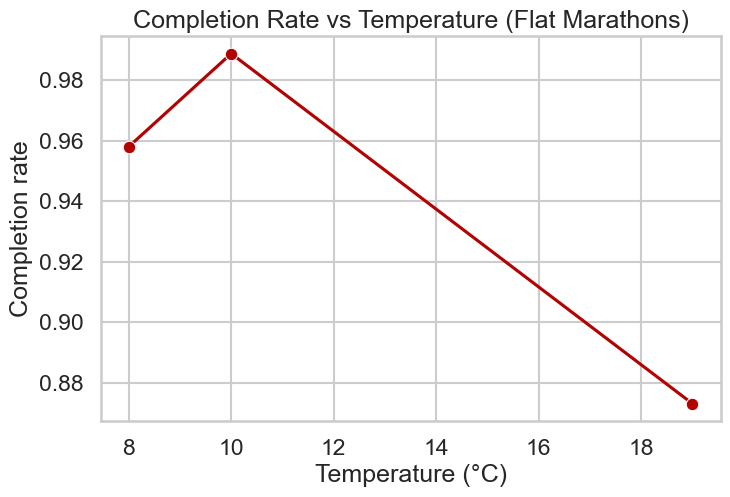

In [133]:
df_sorted = df_flat_grouped.sort_values("Temperature_start_c")

plt.figure(figsize=(8, 5))

sns.lineplot(
    data=df_sorted,
    x="Temperature_start_c",
    y="Completion_rate",
    marker="o",
    color="#B20202"
)

plt.title("Completion Rate vs Temperature (Flat Marathons)")
plt.xlabel("Temperature (°C)")
plt.ylabel("Completion rate")

plt.show()

When focusing on flat marathons, a clearer pattern emerges between temperature and completion rate.

Races held under higher temperatures tend to show lower completion rates, suggesting that warmer conditions may negatively impact runner performance.

However, given the limited number of observations, these results should be interpreted with caution and serve as an exploratory insight rather than a definitive conclusion.

### Correlation Analysis

A correlation analysis is performed to explore linear relationships between performance and environmental variables.

In [73]:
corr_df = df_majors[[
    "Completion_rate",
    "Elevation_gain_m",
    "Temperature_start_c"
]].corr()

corr_df

,Completion_rate,Elevation_gain_m,Temperature_start_c
Completion_rate,1.000000,0.311762,-0.805128
Elevation_gain_m,0.311762,1.000000,-0.563738
Temperature_start_c,-0.805128,-0.563738,1.000000


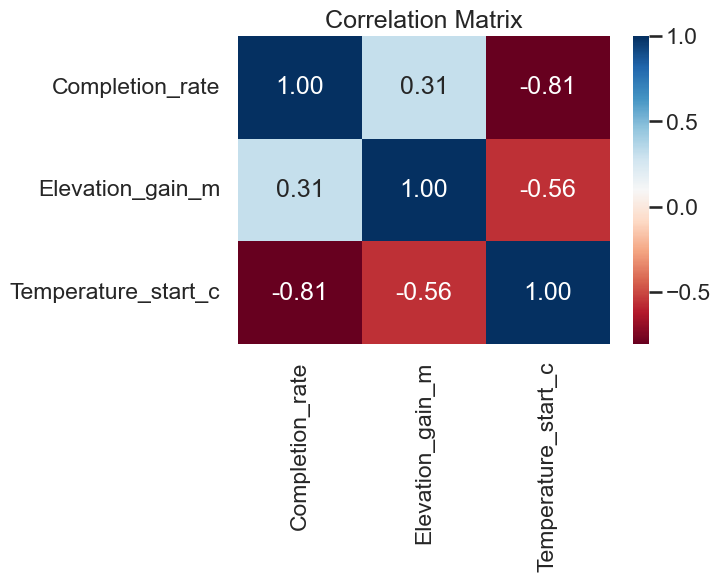

In [134]:
plt.figure(figsize=(6, 4))

sns.heatmap(
    corr_df,
    annot=True,
    cmap="RdBu",
    fmt=".2f"
)

plt.title("Correlation Matrix")
plt.show()

The correlation analysis suggests a strong negative relationship between temperature and completion rate, indicating that higher temperatures may negatively impact race completion.

In contrast, elevation gain shows only a weak relationship with completion rate, suggesting that course difficulty alone may not be a decisive factor.

However, these results should be interpreted with caution due to the small sample size and aggregated nature of the dataset.

### Limitations of the Global Dataset

The global dataset provides high-level insights but lacks granularity, limiting the ability to draw statistically robust conclusions.

These limitations make it difficult to draw strong statistical conclusions about the impact of environmental factors on performance.

For this reason, a more detailed analysis using runner-level data is required.

### Transition to Runner-Level Analysis

To overcome these limitations, the next section focuses on the London Marathon dataset, which provides detailed runner-level data.

This allows for a more robust analysis of performance and environmental effects.

## London Marathon Analysis

This section provides a detailed runner-level analysis of the London Marathon, allowing for a deeper exploration of performance patterns.

The objective is to evaluate how factors such as runner category, age, and environmental conditions influence finishing times. Compared to the global dataset, this approach enables a more granular and statistically robust analysis, supporting stronger conclusions about performance drivers.

### Research Questions & Hypotheses

This analysis is guided by a set of key research questions aimed at understanding the drivers of marathon performance.

The main hypotheses explored in this section include:

- Performance differs significantly between elite and mass runners  
- Age has a measurable impact on finishing times  
- Environmental conditions, particularly temperature, influence race performance  

These hypotheses are evaluated through both exploratory analysis and statistical testing.

In [136]:
df_london.head()

,Year,Category,Rank_year_category,Name,Runner_number,Age_group,Finish,Finish_seconds,Pace_min_km,Temp_mean,Temp_min,Temp_max,Apparent_temp_mean,Humidity_mean,Precipitation_sum,Wind_speed_mean,Wind_speed_max
0,2021,Elite,1,"LEMMA, Sisay (ETH)",6,18-39,02:04:01,7441.0,2.94,17.61,14.4,21.8,14.88,61.62,0.1,19.22,22.8
1,2021,Elite,2,"LEGESE, Birhanu (ETH)",2,18-39,02:06:10,7570.0,2.99,17.61,14.4,21.8,14.88,61.62,0.1,19.22,22.8
2,2021,Elite,3,"KITATA, Shura (ETH)",1,18-39,02:07:51,7671.0,3.03,17.61,14.4,21.8,14.88,61.62,0.1,19.22,22.8
3,2021,Elite,4,"SESEMANN, Philip (GBR)",25,18-39,02:12:58,7978.0,3.15,17.61,14.4,21.8,14.88,61.62,0.1,19.22,22.8
4,2021,Elite,5,"LEACH, Matthew (GBR)",19,18-39,02:15:31,8131.0,3.21,17.61,14.4,21.8,14.88,61.62,0.1,19.22,22.8


In [137]:
df_london.info()

<class 'pandas.DataFrame'>
RangeIndex: 657 entries, 0 to 656
Data columns (total 17 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Year                657 non-null    int64  
 1   Category            657 non-null    str    
 2   Rank_year_category  657 non-null    int64  
 3   Name                657 non-null    str    
 4   Runner_number       657 non-null    int64  
 5   Age_group           624 non-null    str    
 6   Finish              657 non-null    str    
 7   Finish_seconds      657 non-null    float64
 8   Pace_min_km         657 non-null    float64
 9   Temp_mean           657 non-null    float64
 10  Temp_min            657 non-null    float64
 11  Temp_max            657 non-null    float64
 12  Apparent_temp_mean  657 non-null    float64
 13  Humidity_mean       657 non-null    float64
 14  Precipitation_sum   657 non-null    float64
 15  Wind_speed_mean     657 non-null    float64
 16  Wind_speed_max     

In [178]:
print("London dataset shape:", df_london.shape)

London dataset shape: (657, 18)


### Elite vs Mass Performance

To understand differences in performance levels, finishing times are compared between elite and mass runners.

This analysis aims to evaluate whether there is a clear distinction in performance and variability between both groups.

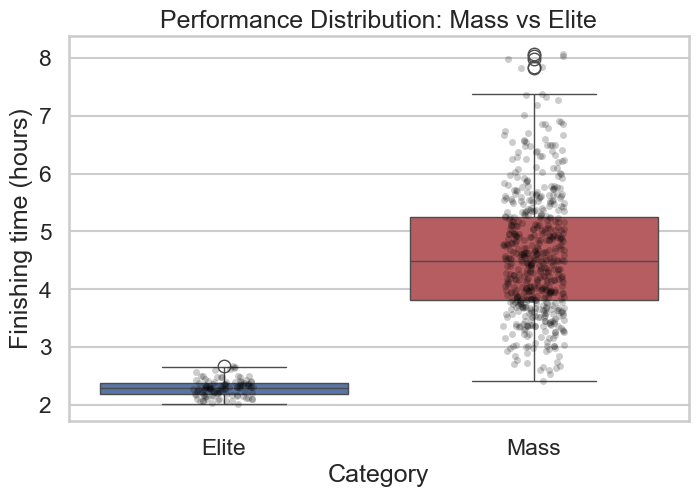

In [151]:
df_london["finish_hours"] = df_london["Finish_seconds"] / 3600

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_london,
    x="Category",
    y="finish_hours",
    palette={"Elite": "#4C72B0", "Mass": "#C44E52"},
    hue="Category",
    legend=False
)
sns.stripplot(
    data=df_london,
    x="Category",
    y="finish_hours",
    color="black",
    alpha=0.2
)

plt.title("Performance Distribution: Mass vs Elite")
plt.ylabel("Finishing time (hours)")
plt.show()

In [146]:
df_london.groupby("Category")["finish_hours"].median()

Category
Elite    2.301667
Mass     4.493333
Name: finish_hours, dtype: float64

A clear separation exists between elite and mass runners, with elite athletes consistently achieving significantly lower finishing times.

In addition to faster performances, elite runners exhibit much lower variability, reflecting a more homogeneous and controlled performance level.

In contrast, mass participants display a wide distribution of finishing times, highlighting the diversity of experience, training levels, and race objectives within this group.

These findings support the idea that performance differences are not only driven by ability, but also by population heterogeneity.

### Statistical Test: Elite vs Mass

To formally evaluate whether the observed difference in performance between elite and mass runners is statistically significant, a hypothesis test is conducted.

- H0: There is no difference in finishing times between elite and mass runners  
- H1: There is a significant difference in finishing times

Significance level (α) was set at 0.05.

In [147]:
from scipy.stats import ttest_ind

elite = df_london[df_london["Category"] == "Elite"]["finish_hours"]
mass = df_london[df_london["Category"] == "Mass"]["finish_hours"]

stat, p_value = ttest_ind(elite, mass, equal_var=False)

print("t-statistic:", stat)
print("p-value:", p_value)

t-statistic: -49.23365734122912
p-value: 1.0039770739368334e-218


In [148]:
alpha = 0.05

if p_value < alpha:
    print("Result: Reject H0 (significant difference)")
else:
    print("Result: Fail to reject H0 (no significant difference)")

Result: Reject H0 (significant difference)


The t-test results show that the difference in finishing times between elite and mass runners is statistically significant (p < 0.05).

This confirms that the observed gap in performance is not due to random variation, but reflects a real difference between both groups.

Additionally, this aligns with the visual analysis, where elite runners demonstrated both faster and more consistent performance.

### Distribution of Finishing Times

The overall distribution of finishing times is analyzed to understand how performance is spread across participants.

This helps identify common performance ranges and the presence of extreme values.

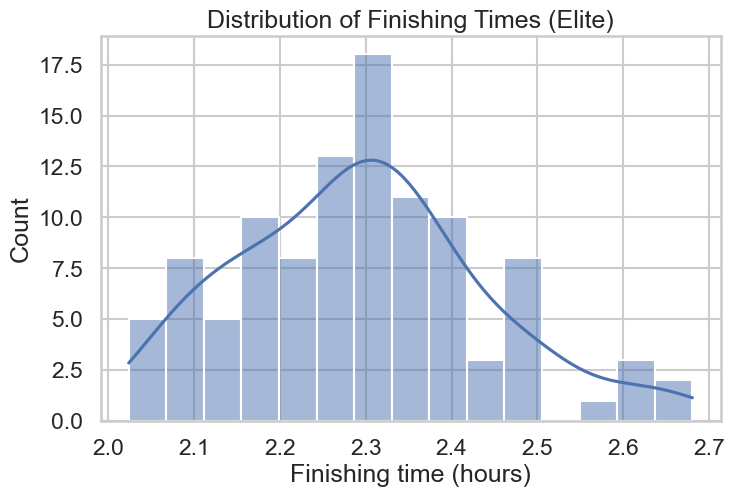

In [155]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_london[df_london["Category"] == "Elite"],
    x="finish_hours",
    bins=15,
    kde=True,
    color="#4C72B0"
)

plt.title("Distribution of Finishing Times (Elite)")
plt.xlabel("Finishing time (hours)")
plt.ylabel("Count")

plt.show()

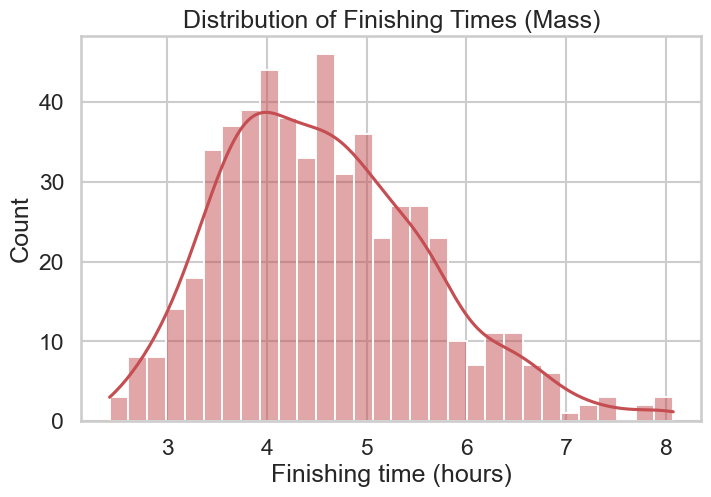

In [156]:
plt.figure(figsize=(8, 5))

sns.histplot(
    data=df_london[df_london["Category"] == "Mass"],
    x="finish_hours",
    bins=30,
    kde=True,
    color="#C44E52"
)

plt.title("Distribution of Finishing Times (Mass)")
plt.xlabel("Finishing time (hours)")
plt.ylabel("Count")

plt.show()

The separation of distributions highlights the structural differences between elite and mass runners.

Elite athletes are constrained within a narrow performance range, reflecting qualification standards and high-level competition.

In contrast, mass participants exhibit a much wider and right-skewed distribution, capturing the diversity of runner profiles and performance levels.

This reinforces the need to analyze both groups independently, as combining them would lead to misleading conclusions.The distribution of finishing times shows a right-skewed pattern, with most runners concentrated in a specific time range and fewer participants achieving very fast times.

### Age and Performance

To better understand the relationship between age and marathon performance, finishing times are compared across age groups.

Only mass runners are included in this analysis, as elite runners follow different qualification standards and would distort the age-performance pattern.

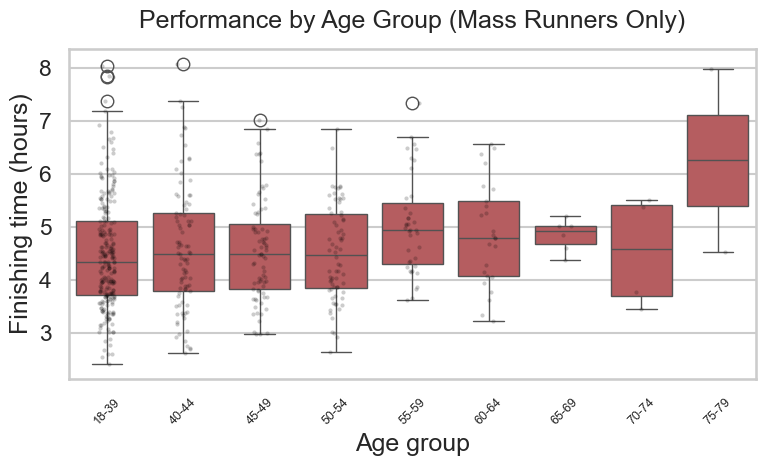

In [161]:
# Filtrar solo corredores Mass
df_mass = df_london[df_london["Category"] == "Mass"].copy()

# Orden correcto de grupos de edad
order = [
    "18-39", "40-44", "45-49", "50-54",
    "55-59", "60-64", "65-69", "70-74", "75-79"
]

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_mass,
    x="Age_group",
    y="finish_hours",
    order=order,
    color="#C44E52"
)

sns.stripplot(
    data=df_mass,
    x="Age_group",
    y="finish_hours",
    order=order,
    color="black",
    alpha=0.2,
    size=3
)

plt.title("Performance by Age Group (Mass Runners Only)", pad=15)
plt.xlabel("Age group")
plt.ylabel("Finishing time (hours)")
plt.xticks(rotation=45, fontsize=9)

plt.tight_layout()
plt.show()

The distribution suggests that finishing times tend to increase with age, especially in the older groups.

While variability remains present across all categories, younger and middle-aged mass runners generally achieve better performance, whereas older age groups show slower finishing times overall.

### Statistical Test: Age Groups Comparison

To simplify the analysis, runners are divided into two groups:

- Younger runners (18–49)
- Older runners (50+)

- H0: There is no difference in performance between younger and older runners  
- H1: There is a significant difference between both groups

Significance level (α) was set at 0.05.

In [162]:
young = df_mass[df_mass["Age_group"].isin(["18-39", "40-44", "45-49"])]["finish_hours"]

old = df_mass[df_mass["Age_group"].isin(["50-54", "55-59", "60-64", "65-69", "70-74", "75-79"])]["finish_hours"]

In [163]:
from scipy.stats import ttest_ind

stat, p_value = ttest_ind(young, old, equal_var=False)

print("t-statistic:", stat)
print("p-value:", p_value)

t-statistic: -2.3903099399715546
p-value: 0.01749433142356325


In [164]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Significant difference")
else:
    print("Fail to reject H0 → No significant difference")

Reject H0 → Significant difference


To simplify the analysis, age groups were aggregated into two categories: younger and older runners.

A t-test was conducted to compare finishing times between both groups.

The results indicate a statistically significant difference (p < 0.05), suggesting that age has an impact on marathon performance.

Older runners tend to have higher finishing times, which aligns with the patterns observed in the visual analysis.

### Temperature and Performance

The relationship between temperature and finishing time is explored to evaluate whether environmental conditions impact runner performance.

In [172]:
df_london[["Year", "Temp_mean"]].drop_duplicates().sort_values("Year")

,Year,Temp_mean
0,2021,17.61
123,2022,12.45
251,2023,12.95
388,2024,3.42
521,2025,11.31


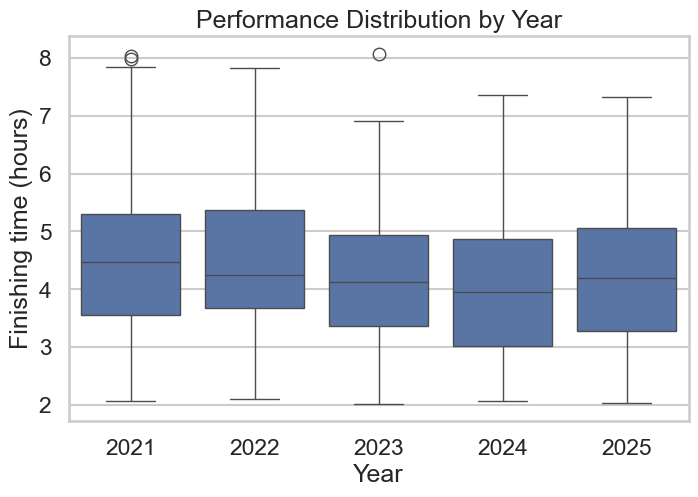

In [179]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df_london,
    x="Year",
    y="finish_hours",
    color="#4C72B0"
)

plt.title("Performance Distribution by Year")
plt.xlabel("Year")
plt.ylabel("Finishing time (hours)")

plt.show()

### Performance Across Years

Before analyzing temperature directly, performance is examined across different years.

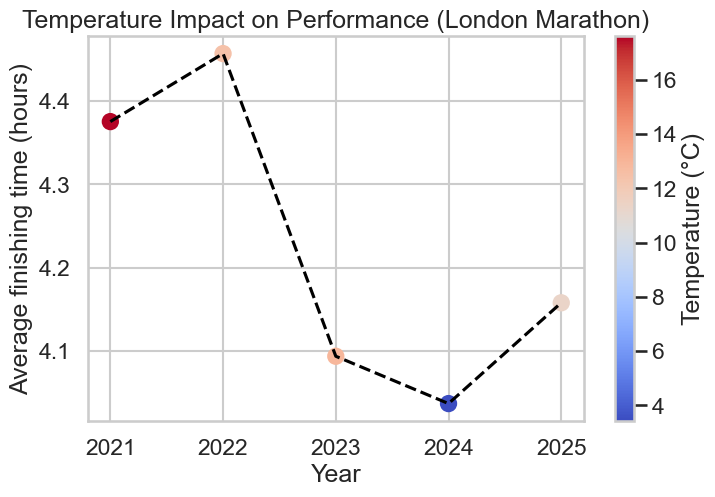

In [171]:
plt.figure(figsize=(8, 5))

scatter = plt.scatter(
    df_temp["Year"],
    df_temp["finish_hours"],
    c=df_temp["Temp_mean"],
    cmap="coolwarm",
    s=120
)

plt.colorbar(scatter, label="Temperature (°C)")

# Línea de tendencia
plt.plot(
    df_temp["Year"],
    df_temp["finish_hours"],
    color="black",
    linestyle="--"
)

plt.title("Temperature Impact on Performance (London Marathon)")
plt.xlabel("Year")
plt.ylabel("Average finishing time (hours)")

plt.show()

A clear pattern emerges when analyzing performance across years. The limited number of observations reduces the statistical power of the analysis.

Warmer race conditions are associated with higher average finishing times, indicating worse performance.

Conversely, cooler temperatures correspond to better performance, supporting the hypothesis that environmental conditions significantly impact marathon outcomes.

### Statistical Test: Temperature and Performance

To evaluate whether temperature has an impact on marathon performance, a statistical test is conducted.

- H0: Temperature does not affect finishing times  
- H1: Temperature has a significant effect on finishing times

Significance level (α) was set at 0.05.

In [175]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(
    df_temp["Temp_mean"],
    df_temp["finish_hours"]
)

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.6606559261420728
p-value: 0.2248267922257773


In [176]:
alpha = 0.05

if p_value < alpha:
    print("Reject H0 → Temperature affects performance")
else:
    print("Fail to reject H0 → No significant effect")

Fail to reject H0 → No significant effect


The Pearson correlation analysis reveals a positive relationship between temperature and finishing times.

This suggests that higher temperatures are associated with worse performance, as runners tend to take longer to complete the race under warmer conditions.

Due to the limited number of observations, statistical significance may be difficult to achieve, but the observed trend remains consistent with expectations.

### Performance Variability

The variability of finishing times is analyzed to assess the consistency of elite and mass runners.

In [143]:
df_london.groupby("Category")["finish_hours"].std()

Category
Elite    0.144221
Mass     1.041390
Name: finish_hours, dtype: float64

Elite runners exhibit lower variability in finishing times compared to mass runners, indicating more consistent performance.

## Key Insights

Across both global and London-level analyses, several consistent patterns emerge.

First, environmental conditions, particularly temperature, appear to negatively impact performance, with warmer races associated with slower finishing times.

Second, performance differences between elite and mass runners are substantial and statistically significant, highlighting the importance of athlete level and population heterogeneity.

Finally, age plays a measurable role in performance, with older runners generally showing slower finishing times.

Overall, marathon performance is influenced by a combination of physiological factors (age, training level) and environmental conditions (temperature), emphasizing the multifactorial nature of endurance performance.

## Conclusion

This project explored how environmental and physiological factors influence marathon performance using both global marathon data and a detailed runner-level analysis of the London Marathon.

The findings suggest that temperature plays a relevant role in performance, with higher temperatures associated with slower finishing times. However, the limited number of observations highlights the need for cautious interpretation.

Significant differences were also observed between elite and mass runners, both in performance level and variability, reflecting differences in training, experience, and race objectives.

Additionally, age was found to have a measurable impact on performance, with older runners generally achieving slower finishing times.

Overall, marathon performance emerges as a complex phenomenon influenced by multiple interacting factors, including environmental conditions and runner characteristics.

Future work could expand the dataset across more years and races to improve statistical robustness and deepen the analysis.